In [1]:
import os

# Ensure the kernel loads the modern CUDA toolkit DLLs first (avoid old Anaconda NVRTC 11.2)
CUDA_BIN = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.2\bin\x64"
if os.path.isdir(CUDA_BIN):
    os.add_dll_directory(CUDA_BIN)

# Put CUDA toolkit path first and drop base Anaconda Library\bin if present.
# This prevents loading nvrtc64_112_0.dll from base env.
path_entries = os.environ.get("PATH", "").split(";")
filtered = [p for p in path_entries if "anaconda3\\library\\bin" not in p.lower()]
os.environ["PATH"] = CUDA_BIN + ";" + ";".join(filtered)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import time
from numba import cuda
import math

In [2]:
# X, _ = make_blobs(n_samples=1000000, n_features=100, centers=20, random_state=42)

# df = pd.DataFrame(X)
# df.to_csv("kmeans_benchmark_data.csv", index=False, header=False)
# print("Dataset generated successfully!")

In [4]:
X = pd.read_csv(r"C:\Users\elbaz\kmeans_benchmark_data.csv", header=None).values
Xs = StandardScaler().fit_transform(X)

ks = range(2, 30)
inertias = []
sils = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xs)
    
    # Inertia is fast to calculate, no changes needed here
    inertias.append(km.inertia_)
    
    # THE FIX: Calculate silhouette score on a random 20,000 point sample
    sil_score = silhouette_score(Xs, labels, sample_size=20000, random_state=42)
    sils.append(sil_score)
    
    print(f"Finished k={k} | Inertia: {km.inertia_:.2f} | Silhouette: {sil_score:.4f}")

c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Finished k=2 | Inertia: 44078390.56 | Silhouette: 0.1008
Finished k=3 | Inertia: 40657523.69 | Silhouette: 0.1392
Finished k=4 | Inertia: 37900980.03 | Silhouette: 0.1726
Finished k=5 | Inertia: 35537580.05 | Silhouette: 0.2086
Finished k=6 | Inertia: 32077375.78 | Silhouette: 0.2597
Finished k=7 | Inertia: 30034102.29 | Silhouette: 0.2905
Finished k=8 | Inertia: 26926154.15 | Silhouette: 0.3393
Finished k=9 | Inertia: 24486457.96 | Silhouette: 0.3803
Finished k=10 | Inertia: 22314885.64 | Silhouette: 0.4192
Finished k=11 | Inertia: 19632772.97 | Silhouette: 0.4627
Finished k=12 | Inertia: 17673096.73 | Silhouette: 0.4972
Finished k=13 | Inertia: 15003689.19 | Silhouette: 0.5410
Finished k=14 | Inertia: 12978194.94 | Silhouette: 0.5785
Finished k=15 | Inertia: 11139560.58 | Silhouette: 0.6132
Finished k=16 | Inertia: 8923143.57 | Silhouette: 0.6572
Finished k=17 | Inertia: 7110636.53 | Silhouette: 0.6913
Finished k=18 | Inertia: 5152743.23 | Silhouette: 0.7323
Finished k=19 | Inertia: 

NameError: name 'plt' is not defined

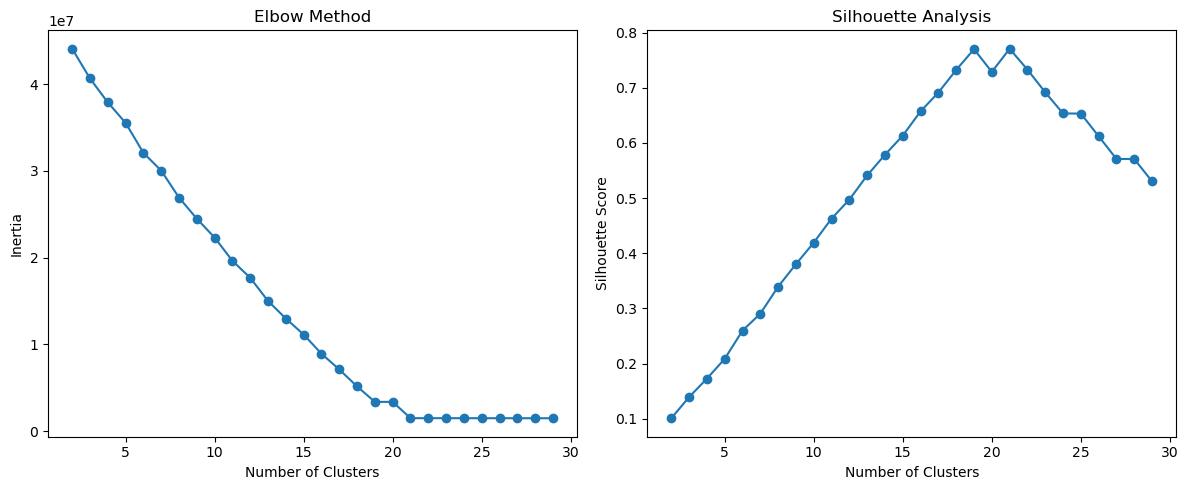

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(ks, sils, marker='o')
plt.title('Silhouette Analysis')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [2]:
data = pd.read_csv(r"C:\Users\elbaz\kmeans_benchmark_data.csv", header=None).values
n_clusters = 20
start_time = time.time()
kmeans_cpu = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_cpu.fit(data)
cpu_time = time.time() - start_time
print(f"CPU K-means time: {cpu_time:.4f} seconds")

CPU K-means time: 5.2702 seconds


c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [3]:
Xs = StandardScaler().fit_transform(data)

In [4]:
Xs.astype(np.float32).tofile("benchmark_data.bin")

In [30]:
import math
import numpy as np
from numba import cuda
import time
import numba

MAX_CLUSTERS = 32
MAX_FEATURES = 128

MAX_CENTROID_SIZE = MAX_CLUSTERS * MAX_FEATURES 

# ---------------------------------------------------------
# KERNEL 1: Zero out tracking arrays directly on the GPU
# ---------------------------------------------------------
@cuda.jit(fastmath=True)
def reset_arrays_kernel(cluster_sums, cluster_counts, changes, n_clusters, n_features):
    idx = cuda.grid(1)
    
    # Zero out the flat 1D sums array
    if idx < (n_clusters * n_features):
        cluster_sums[idx] = 0.0
        
    # Zero out the counts and the changes tracker
    if idx < n_clusters:
        cluster_counts[idx] = 0
        if idx == 0:
            changes[0] = 0

# ---------------------------------------------------------
# KERNEL 2: Assign clusters and track if anything changed
# ---------------------------------------------------------
# Make sure MAX_CLUSTERS and MAX_FEATURES are defined above this
@cuda.jit(fastmath=True)
def assign_clusters_kernel(X, centroids, assignments, distances, changes, n_samples, n_clusters, n_features):
    # L1 Cache for centroids
    shared_centroids = cuda.shared.array(MAX_CENTROID_SIZE, dtype=numba.float32)
    
    # Thread Registers: The fastest memory on the GPU (Zero latency)
    dists = cuda.local.array(MAX_CLUSTERS, dtype=numba.float32)
    
    tx = cuda.threadIdx.x
    bw = cuda.blockDim.x
    i = cuda.grid(1)
    
    # Load centroids to L1 Cache
    for idx in range(tx, n_clusters * n_features, bw):
        c = idx // n_features
        f = idx % n_features
        shared_centroids[idx] = centroids[c, f]
        
    cuda.syncthreads()
    
    if i < n_samples:
        # Initialize register distances to zero
        for c in range(n_clusters):
            dists[c] = 0.0
            
        # THE MAGIC FLIP: Features on the outside, Clusters on the inside!
        for f in range(n_features):
            
            # WE READ FROM VRAM EXACTLY ONCE PER FEATURE
            x_val = X[i, f] 
            
            for c in range(n_clusters):
                c_idx = c * n_features + f
                diff = x_val - shared_centroids[c_idx]
                dists[c] += diff * diff
                
        # Find the best cluster
        min_dist = numba.float32(1e30)
        best_cluster = 0
        for c in range(n_clusters):
            if dists[c] < min_dist:
                min_dist = dists[c]
                best_cluster = c
                
        # Flag if a point changed clusters
        if assignments[i] != best_cluster:
            cuda.atomic.add(changes, 0, 1)
            
        assignments[i] = best_cluster
        distances[i] = math.sqrt(min_dist)
# ---------------------------------------------------------
# KERNEL 3: Sum the points (Same as yours, but kept strictly on GPU)
# ---------------------------------------------------------
@cuda.jit(fastmath=True)
def sum_points_kernel(X, assignments, cluster_sums, cluster_counts, n_samples, n_features, n_clusters):
    # 1. Allocate Shared Memory for local block tallies
    shared_sums = cuda.shared.array(MAX_CENTROID_SIZE, dtype=numba.float32)
    shared_counts = cuda.shared.array(MAX_CLUSTERS, dtype=numba.int32)
    
    tx = cuda.threadIdx.x
    bw = cuda.blockDim.x
    i = cuda.grid(1)
    
    # 2. Initialize L1 cache to zero
    for idx in range(tx, n_clusters * n_features, bw):
        shared_sums[idx] = 0.0
    if tx < n_clusters:
        shared_counts[tx] = 0
        
    cuda.syncthreads()
    
    # 3. Compute sums LOCALLY in L1 cache (bypasses global traffic jams)
    if i < n_samples:
        cluster = assignments[i]
        cuda.atomic.add(shared_counts, cluster, 1)
        
        for f in range(n_features):
            idx = cluster * n_features + f
            cuda.atomic.add(shared_sums, idx, X[i, f])
            
    cuda.syncthreads()
    
    # 4. Write the final local tally to Global Memory in one smooth burst
    for idx in range(tx, n_clusters * n_features, bw):
        if shared_sums[idx] != 0.0:
            cuda.atomic.add(cluster_sums, idx, shared_sums[idx])
            
    if tx < n_clusters:
        if shared_counts[tx] > 0:
            cuda.atomic.add(cluster_counts, tx, shared_counts[tx])

# ---------------------------------------------------------
# KERNEL 4: Calculate new centroids on the GPU
# ---------------------------------------------------------
@cuda.jit(fastmath=True)
def update_centroids_kernel(centroids, cluster_sums, cluster_counts, n_clusters, n_features):
    c = cuda.grid(1)
    
    # One thread per cluster
    if c < n_clusters:
        count = cluster_counts[c]
        if count > 0:
            for f in range(n_features):
                idx = c * n_features + f
                centroids[c, f] = cluster_sums[idx] / count

# ---------------------------------------------------------
# MAIN FUNCTION
# ---------------------------------------------------------
def kmeans_numba_optimized(X, n_clusters=20, max_iter=50, random_state=42, threads_per_block=256):
    
    X = np.asfortranarray(X, dtype=np.float32)
    n_samples = int(X.shape[0])
    n_features = int(X.shape[1])
    n_clusters = int(n_clusters)
    
    rng = np.random.default_rng(random_state)
    init_idx = rng.choice(n_samples, size=n_clusters, replace=False)
    centroids = np.ascontiguousarray(X[init_idx], dtype=np.float32)
    
    # Send initial data to GPU
    d_X = cuda.to_device(X)
    d_centroids = cuda.to_device(centroids)
    
    # Pre-allocate all memory arrays on the device ONCE
    d_assignments = cuda.device_array(n_samples, dtype=np.int32)
    d_distances = cuda.device_array(n_samples, dtype=np.float32)
    d_cluster_sums = cuda.device_array(n_clusters * n_features, dtype=np.float32)
    d_cluster_counts = cuda.device_array(n_clusters, dtype=np.int32)
    d_changes = cuda.device_array(1, dtype=np.int32) # Convergence tracker
    
    # Calculate grid sizes
    blocks_samples = (n_samples + threads_per_block - 1) // threads_per_block
    blocks_clusters = (n_clusters * n_features + threads_per_block - 1) // threads_per_block
    
    start_time = time.perf_counter()
    
    for iteration in range(max_iter):
        
        # Step 1: Wipe the temporary arrays directly on the GPU
        reset_arrays_kernel[blocks_clusters, threads_per_block](
            d_cluster_sums, d_cluster_counts, d_changes, n_clusters, n_features
        )
        cuda.synchronize()
        
        # Step 2: Assign Clusters
        assign_clusters_kernel[blocks_samples, threads_per_block](
            d_X, d_centroids, d_assignments, d_distances, d_changes,
            n_samples, n_clusters, n_features
        )
        cuda.synchronize()
        
        # Check Convergence by downloading ONLY ONE integer
        changes = d_changes.copy_to_host()[0]
        if iteration > 0 and changes == 0:
            print(f"Converged at iteration {iteration}")
            break
            
        # Step 3: Sum Points
        sum_points_kernel[blocks_samples, threads_per_block](
            d_X, d_assignments, d_cluster_sums, d_cluster_counts, 
            n_samples, n_features, n_clusters
        )
        cuda.synchronize()
        
        # Step 4: Update Centroids directly on the GPU
        update_centroids_kernel[blocks_clusters, threads_per_block](
            d_centroids, d_cluster_sums, d_cluster_counts, n_clusters, n_features
        )
        cuda.synchronize()
    
    gpu_kernel_time = time.perf_counter() - start_time
    
    # Only pull the final data back when everything is completely finished
    final_assignments = d_assignments.copy_to_host()
    final_centroids = d_centroids.copy_to_host()
    
    return {
        "centroids": final_centroids,
        "labels": final_assignments,
        "gpu_kernel_time_sec": gpu_kernel_time,
    }

In [31]:
candidate_threads = [64, 128, 256, 512]

if "data" not in globals() or "n_clusters" not in globals():
    print("Run the data preparation cells first.")
else:
    tune_rows = min(50000, len(data))
    tune_data = np.ascontiguousarray(data[:tune_rows], dtype=np.float32)
    print(f"Tuning thread blocks on {tune_rows} samples")
    
    tune_results = []
    for threads_per_block in candidate_threads:
        try:
            start_time = time.perf_counter()
            result = kmeans_numba_optimized(
                tune_data,
                n_clusters=n_clusters,
                max_iter=5,
                random_state=42,
                threads_per_block=threads_per_block,
            )
            wall_time = time.perf_counter() - start_time
            tune_results.append((threads_per_block, result["gpu_kernel_time_sec"], wall_time))
            print(
                f"TPB={threads_per_block:>3} | kernel={result['gpu_kernel_time_sec']:.4f}s | "
                f"end-to-end={wall_time:.4f}s"
            )
        except Exception as e:
            print(f"TPB={threads_per_block:>3} failed: {e}")
    
    if tune_results:
        best_kernel = min(tune_results, key=lambda item: item[1])
        best_wall = min(tune_results, key=lambda item: item[2])
        print(f"Best kernel time: TPB={best_kernel[0]} ({best_kernel[1]:.4f}s)")
        print(f"Best end-to-end time: TPB={best_wall[0]} ({best_wall[2]:.4f}s)")
    else:
        print("No CUDA configuration completed successfully.")

Tuning thread blocks on 50000 samples


c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


TPB= 64 | kernel=0.5970s | end-to-end=0.6130s
TPB=128 | kernel=0.0271s | end-to-end=0.0465s
TPB=256 | kernel=0.0457s | end-to-end=0.0615s
TPB=512 | kernel=0.0327s | end-to-end=0.0479s
Best kernel time: TPB=128 (0.0271s)
Best end-to-end time: TPB=128 (0.0465s)


c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 98 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [32]:
print("Warming up GPU compiler...")
# Pass a tiny slice of data just to trigger the compiler
_ = kmeans_numba_optimized(data[:1000], n_clusters=32, max_iter=2)

print("Starting REAL benchmark...")
start = time.perf_counter()
result = kmeans_numba_optimized(data, n_clusters=32, max_iter=50)
gpu_time = time.perf_counter() - start

print(f"Final GPU Time: {gpu_time:.4f} seconds")

Warming up GPU compiler...
Starting REAL benchmark...


c:\Users\elbaz\Anaconda3\envs\kmeans_env\lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 13 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Final GPU Time: 0.6979 seconds


In [33]:
required_vars = ["data", "n_clusters", "cpu_time"]
missing = [name for name in required_vars if name not in globals()]

print("Warming up GPU...")
_ = kmeans_numba_optimized(data[:1000], n_clusters=32, max_iter=2)

if missing:
    print("Please run the data preparation and CPU benchmark cells first. Missing:", ", ".join(missing))
else:
    print(f"CPU K-means time: {cpu_time:.4f} seconds")

    # Benchmark Numba CUDA implementation
    numba_start = time.perf_counter()
    numba_result = kmeans_numba_optimized(
        data,
        n_clusters=n_clusters,
        max_iter=20,
        random_state=42,
    )
    numba_wall_time = time.perf_counter() - numba_start

    print(f"GPU (Numba CUDA) kernel time: {numba_result['gpu_kernel_time_sec']:.4f} seconds")
    print(f"GPU (Numba CUDA) end-to-end time: {numba_wall_time:.4f} seconds")

    if numba_result["gpu_kernel_time_sec"] > 0:
        print(f"Speedup vs CPU (Numba kernel): {cpu_time / numba_result['gpu_kernel_time_sec']:.2f}x")
    if numba_wall_time > 0:
        print(f"Speedup vs CPU (Numba end-to-end): {cpu_time / numba_wall_time:.2f}x")

    # Benchmark CuPy implementation only if present in the notebook
    if "kmeans_cupy" in globals():
        cupy_start = time.perf_counter()
        cupy_result = kmeans_cupy(
            data,
            n_clusters=n_clusters,
            max_iter=20,
            random_state=42,
            tol=1e-3,
            use_float16=True,
            check_every=4,
        )
        cupy_wall_time = time.perf_counter() - cupy_start

        print(f"GPU (CuPy) kernel time: {cupy_result['gpu_kernel_time_sec']:.4f} seconds")
        print(f"GPU (CuPy) end-to-end time: {cupy_wall_time:.4f} seconds")

        if cupy_result["gpu_kernel_time_sec"] > 0:
            print(f"Speedup vs CPU (CuPy kernel): {cpu_time / cupy_result['gpu_kernel_time_sec']:.2f}x")
        if cupy_wall_time > 0:
            print(f"Speedup vs CPU (CuPy end-to-end): {cpu_time / cupy_wall_time:.2f}x")
    else:
        print("CuPy benchmark skipped (kmeans_cupy is not defined in this notebook run).")

Warming up GPU...
CPU K-means time: 5.2702 seconds
GPU (Numba CUDA) kernel time: 0.1161 seconds
GPU (Numba CUDA) end-to-end time: 0.1946 seconds
Speedup vs CPU (Numba kernel): 45.39x
Speedup vs CPU (Numba end-to-end): 27.08x
CuPy benchmark skipped (kmeans_cupy is not defined in this notebook run).
